# spaCy 101: Everything you need to know
https://spacy.io/usage/spacy-101

In [2]:
import spacy
# https://spacy.io/usage/visualizers
from spacy import displacy

from spacy.tokens import Doc, Span, DocBin
from spacy.vocab import Vocab
from spacy.language import Language

# https://spacy.io/usage/rule-based-matching
from spacy.matcher import Matcher, PhraseMatcher, DependencyMatcher

from spacy.training import Example
from spacy.util import minibatch

from spacy.kb import InMemoryLookupKB

import pandas as pd
import matplotlib.pyplot as plt

import random
from pathlib import Path
import os
from collections import Counter
from typing import Callable, Iterable
from functools import partial

# jsonl
import srsly
# annoatation
from nertk import Entator

from IPython.display import display, HTML

display(HTML("""
<style>
    .dataframe th {
        text-align: left !important;
    }
    .dataframe td {
        text-align: left !important;
    }
</style>
"""))

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.colheader_justify', 'left')

# df.style.set_table_styles([
#     {'selector': 'th', 'props': [('text-align', 'left')]},
#     {'selector': 'td', 'props': [('text-align', 'left')]}
# ])
# df.style.set_properties(**{'text-align': 'left'})

In [8]:
# get spacy info
spacy.info()

{'spacy_version': '3.8.14',
 'location': 'd:\\workspace\\github\\hack-ml\\codes\\nlp\\hack-spacy\\.venv\\Lib\\site-packages\\spacy',
 'platform': 'Windows-11-10.0.26200-SP0',
 'python_version': '3.12.3',
 'pipelines': {'en_core_web_sm': '3.8.0',
  'en_core_web_trf': '3.8.0',
  'zh_core_web_lg': '3.8.0',
  'zh_core_web_sm': '3.8.0',
  'zh_core_web_trf': '3.8.0'}}

In [33]:
# get model info
# spacy.info('zh_core_web_sm')

In [2]:
%matplotlib inline

In [ ]:
# import platform
# print(platform.system())

Windows


In [ ]:
# !type custom\custom_functions.py

In [38]:
%%cmd
:: type README.md
findstr /n "^" README.md | findstr "^[1-3]:"

Microsoft Windows [Version 10.0.26200.8246]
(c) Microsoft Corporation. All rights reserved.



(hack-spacy) d:\workspace\github\hack-ml\codes\nlp\hack-spacy>:: type README.md
(hack-spacy) d:\workspace\github\hack-ml\codes\nlp\hack-spacy>findstr /n "^" README.md | findstr "^[1-3]:"
1:# hack spaCy
2:
3:setup

(hack-spacy) d:\workspace\github\hack-ml\codes\nlp\hack-spacy>

In [ ]:
# list packages

# import inspect

# rows = []
# def get_modules(m, level=0):
#   if level > 1:
#     return
#   for mm in inspect.getmembers(m, lambda _m: inspect.ismodule(_m) and _m.__name__.startswith("spacy")):
#     # print("-" * level, mm[0], (mm[1].__doc__ or '').replace("\n", " ")[:200])
#     rows.append((mm[1].__name__, (mm[1].__doc__ or '').replace("\n", " ")[:200]))
#     get_modules(mm[1], level+1)

# get_modules(spacy)

# pd.set_option('display.max_rows', None)
# df = pd.DataFrame(rows, columns=["module", "description"])
# df.style.set_table_styles([
#     {'selector': 'th', 'props': [('text-align', 'left')]}
# ]).set_properties(**{'text-align': 'left'})

# Linguistic annotations

In [ ]:
# Language
nlp = spacy.load("en_core_web_sm")
# Doc
doc = nlp("Apple is looking at buying U.K. startup for $1 billion") 

rows = []
for token in doc:
    #print(token.text, token.pos_, token.dep_)
    rows.append((token.text, token.pos_, token.dep_))
pd.DataFrame.from_records(rows, columns=["text", "pos", "dep"])

,text,pos,dep
0,Apple,PROPN,nsubj
1,is,AUX,aux
2,looking,VERB,ROOT
3,at,ADP,prep
4,buying,VERB,pcomp
5,U.K.,PROPN,nsubj
6,startup,VERB,ccomp
7,for,ADP,prep
8,$,SYM,quantmod
9,1,NUM,compound


## Tokenization

In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")
for token in doc:
    print(token.text)

Apple
is
looking
at
buying
U.K.
startup
for
$
1
billion


## Part-of-speech tags and dependencies

In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")

# for token in doc:
#     print(token.text, token.lemma_, token.pos_, token.tag_, token.dep_,
#             token.shape_, token.is_alpha, token.is_stop)

In [ ]:
rows = []
for token in doc:
    rows.append((token.text, token.lemma_, token.pos_, token.tag_, token.dep_,
            token.shape_, token.is_alpha, token.is_stop))
pd.DataFrame.from_records(rows, columns=["text", "lemma", "pos", "tag", "dep", "shape", "is_alpha", "is_stop"])

,text,lemma,pos,tag,dep,shape,is_alpha,is_stop
0,Apple,Apple,PROPN,NNP,nsubj,Xxxxx,True,False
1,is,be,AUX,VBZ,aux,xx,True,True
2,looking,look,VERB,VBG,ROOT,xxxx,True,False
3,at,at,ADP,IN,prep,xx,True,True
4,buying,buy,VERB,VBG,pcomp,xxxx,True,False
5,U.K.,U.K.,PROPN,NNP,nsubj,X.X.,False,False
6,startup,startup,VERB,VBD,ccomp,xxxx,True,False
7,for,for,ADP,IN,prep,xxx,True,True
8,$,$,SYM,$,quantmod,$,False,False
9,1,1,NUM,CD,compound,d,False,False


In [ ]:
# https://spacy.io/usage/visualizers
# displacy.serve(doc, style="dep")
displacy.render(doc, style="dep")

### Examples

In [20]:
# Mastering spaCy
nlp = spacy.load("en_core_web_sm")
docs = nlp.pipe([
  "I counted white sheep",
  "She has gone",
  "I opened the phone book",
  "The girl is pretty",
  "She gave me the book",
  "Mary took the book",
  "There are 3 books",
  "This is my book",
  "We are trying to understand the difference"
])
for doc in docs:
  displacy.render(doc, style="ent", jupyter=True)
  displacy.render(doc, style="dep", jupyter=True, options={"distance": 140})

d:\workspace\github\hack-ml\codes\nlp\hack-spacy\.venv\Lib\site-packages\spacy\displacy\__init__.py:214: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


## Named Entities

In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")

rows = []
for ent in doc.ents:
    #print(ent.text, ent.start_char, ent.end_char, ent.label_)
    rows.append((ent.text, ent.start_char, ent.end_char, ent.label_))
pd.DataFrame.from_records(rows, columns=["text", "start_char", "end_char", "label"])

,text,start_char,end_char,label
0,Apple,0,5,ORG
1,U.K.,27,31,GPE
2,$1 billion,44,54,MONEY


In [ ]:
# displacy.serve(doc, style="dep")
displacy.render(doc, style="ent")

### Examples

In [ ]:
# Mastering spaCy
doc = nlp("The Brazilian president visited Beijing.")
print(doc.ents)
print(type(doc.ents[0]))
displacy.render(doc, style="ent")

(Brazilian, Beijing)
<class 'spacy.tokens.span.Span'>


In [24]:
doc = nlp("He worked for NASA.")
token = doc[3]
print(token.ent_type_, spacy.explain(token.ent_type_))
displacy.render(doc, style="ent")

ORG Companies, agencies, institutions, etc.


## Word vectors and similarity

In [ ]:
nlp = spacy.load("en_core_web_sm") # en_core_web_lg
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")

rows = []
for ent in doc.ents:
    rows.append((ent.text, ent.vector))
    # print(ent.text, ent.vector)
pd.DataFrame.from_records(rows, columns=["text", "vector"])

,text,vector
0,Apple,"[-0.7522697, -1.0278195, 0.98893344, 0.4298671..."
1,U.K.,"[0.041271746, -1.6439024, 0.07556179, 0.972928..."
2,$1 billion,"[-1.3367996, 0.19592136, 1.6388389, 0.6558214,..."


In [ ]:
nlp = spacy.load("en_core_web_trf")  # make sure to use larger package!
doc1 = nlp("I like salty fries and hamburgers.")
doc2 = nlp("Fast food tastes very good.")

# Similarity of two documents
print(doc1, "<->", doc2, doc1.similarity(doc2))
# Similarity of tokens and spans
french_fries = doc1[2:4]
burgers = doc1[5]
print(french_fries, "<->", burgers, french_fries.similarity(burgers))

I like salty fries and hamburgers. <-> Fast food tastes very good. 0.3173838257789612
salty fries <-> hamburgers 0.2891702353954315


C:\Users\zhouj\AppData\Local\Temp\ipykernel_25416\1096098872.py:9: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  print(doc1, "<->", doc2, doc1.similarity(doc2))
C:\Users\zhouj\AppData\Local\Temp\ipykernel_25416\1096098872.py:13: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Span.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive t

# Pipelines

In [30]:
nlp = spacy.load("en_core_web_sm")

nlp.pipe_names

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

In [31]:
nlp.meta

{'lang': 'en',
 'name': 'core_web_sm',
 'version': '3.8.0',
 'description': 'English pipeline optimized for CPU. Components: tok2vec, tagger, parser, senter, ner, attribute_ruler, lemmatizer.',
 'author': 'Explosion',
 'email': 'contact@explosion.ai',
 'url': 'https://explosion.ai',
 'license': 'MIT',
 'spacy_version': '>=3.8.0,<3.9.0',
 'spacy_git_version': '5010fcbd3',
 'vectors': {'width': 0,
  'vectors': 0,
  'keys': 0,
  'name': None,
  'mode': 'default'},
 'labels': {'tok2vec': [],
  'tagger': ['$',
   "''",
   ',',
   '-LRB-',
   '-RRB-',
   '.',
   ':',
   'ADD',
   'AFX',
   'CC',
   'CD',
   'DT',
   'EX',
   'FW',
   'HYPH',
   'IN',
   'JJ',
   'JJR',
   'JJS',
   'LS',
   'MD',
   'NFP',
   'NN',
   'NNP',
   'NNPS',
   'NNS',
   'PDT',
   'POS',
   'PRP',
   'PRP$',
   'RB',
   'RBR',
   'RBS',
   'RP',
   'SYM',
   'TO',
   'UH',
   'VB',
   'VBD',
   'VBG',
   'VBN',
   'VBP',
   'VBZ',
   'WDT',
   'WP',
   'WP$',
   'WRB',
   'XX',
   '_SP',
   '``'],
  'parser': ['RO

In [32]:
nlp.config

{'paths': {'train': None, 'dev': None, 'vectors': None, 'init_tok2vec': None},
 'system': {'gpu_allocator': None, 'seed': 0},
 'nlp': {'lang': 'en',
  'pipeline': ['tok2vec',
   'tagger',
   'parser',
   'senter',
   'attribute_ruler',
   'lemmatizer',
   'ner'],
  'disabled': ['senter'],
  'before_creation': None,
  'after_creation': None,
  'after_pipeline_creation': None,
  'batch_size': 256,
  'tokenizer': {'@tokenizers': 'spacy.Tokenizer.v1'},
  'vectors': {'@vectors': 'spacy.Vectors.v1'}},
 'components': {'tok2vec': {'factory': 'tok2vec',
   'model': {'embed': {'@architectures': 'spacy.MultiHashEmbed.v2',
     'width': '${components.tok2vec.model.encode:width}',
     'attrs': ['NORM', 'PREFIX', 'SUFFIX', 'SHAPE', 'SPACY', 'IS_SPACE'],
     'rows': [5000, 1000, 2500, 2500, 50, 50],
     'include_static_vectors': False},
    'encode': {'@architectures': 'spacy.MaxoutWindowEncoder.v2',
     'width': 96,
     'depth': 4,
     'window_size': 1,
     'maxout_pieces': 3},
    '@architec

In [ ]:
# Language.add_pipe(...)
# see also: @Language.factory, @Language.component
nlp.add_pipe

## Examples

In [3]:
# Mastering spaCy

df = pd.read_csv("data/atis_intents.csv", header=None, names=["utterance", "text"])
df.describe()

,utterance,text
count,4978,4978
unique,22,4634
top,atis_flight,what is fare code h
freq,3666,8


In [4]:
df.head()

,utterance,text
0,atis_flight,i want to fly from boston at 838 am and arrive in denver at 1110 in the morning
1,atis_flight,what flights are available from pittsburgh to baltimore on thursday morning
2,atis_flight_time,what is the arrival time in san francisco for the 755 am flight leaving washington
3,atis_airfare,cheapest airfare from tacoma to orlando
4,atis_airfare,round trip fares from pittsburgh to philadelphia under 1000 dollars


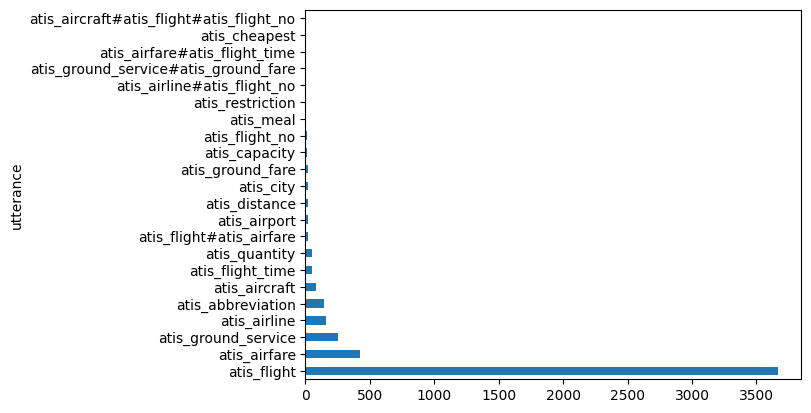

In [8]:
df["utterance"].value_counts().plot(kind="barh")
plt.show()

In [9]:
# NER with SpanRuler

nlp = spacy.load("en_core_web_sm")
text = "i want to fly from boston at 838 am and arrive in denver at 1110 in the morning"

config = {"annotate_ents": True, "overwrite": False}
spanruler_component = nlp.add_pipe("span_ruler", config=config)
patterns_location_spanruler = [
    {"label": "LOCATION",
     "pattern": [{"POS": "ADP"}, {"ENT_TYPE": "GPE"}]}
]
spanruler_component.add_patterns(patterns_location_spanruler)

doc = nlp(text)
displacy.render(doc, style="ent", jupyter=True)

In [ ]:
# dependency relations with DependencyMatcher

class IntentComponent:
  def __init__(self, nlp: Language):
    self.matcher = DependencyMatcher(nlp.vocab) # <---

    pattern = [
        {
            "RIGHT_ID": "direct_object_token",
            "RIGHT_ATTRS": {"DEP": "dobj"}
        },
        {
            "LEFT_ID": "direct_object_token",
            "REL_OP": "<",
            "RIGHT_ID": "verb_token",
            "RIGHT_ATTRS": {"POS": "VERB"}
        }
    ]

    pattern_two = [
        {
            "RIGHT_ID": "direct_object_token",
            "RIGHT_ATTRS": {"DEP": "dobj"}
        },
        {
            "LEFT_ID": "direct_object_token",
            "REL_OP": "<",
            "RIGHT_ID": "verb_token",
            "RIGHT_ATTRS": {"POS": "VERB"}
        },
        {
            "LEFT_ID": "direct_object_token",
            "REL_OP": ">",
            "RIGHT_ID": "conjunction_token",
            "RIGHT_ATTRS": {"DEP": "conj"}
        }
    ]

    self.matcher.add("INTENT", [pattern])
    self.matcher.add("TWO_INTENTS", [pattern_two])

    if not Doc.has_extension("intent"):
      Doc.set_extension("intent", default=None) # <--- extension attribute

  def __call__(self, doc: Doc) -> Doc:
    matches = self.matcher(doc)

    for match_id, token_ids in matches:
      string_id = nlp.vocab.strings[match_id]
      if string_id == "TWO_INTENTS":
        verb_token = doc[token_ids[1]]
        dobj_token = doc[token_ids[0]]
        conj_token = doc[token_ids[2]]
        # [verb][Direct object];[Verb][Conjunction]
        intent = verb_token.lemma_ + dobj_token.lemma_.capitalize() + ";" + \
            verb_token.lemma_ + conj_token.lemma_.capitalize()
        doc._.intent = intent  # <--- extension attribute
        break
    else:
      for match_id, token_ids in matches:
        string_id = nlp.vocab.strings[match_id]
        if string_id == "INTENT":
          verb_token = doc[token_ids[1]]
          dobj_token = doc[token_ids[0]]
          intent = verb_token.lemma_ + dobj_token.lemma_.capitalize()
          doc._.intent = intent  # <--- extension attribute

    return doc


@Language.factory("intent_component")
def create_intent_component(nlp: Language, name: str):  # use extension attributes
  return IntentComponent(nlp)


nlp.add_pipe("intent_component")
text = "show all flights and fares from denver to san francisco"
doc = nlp(text)
doc._.intent

'showFlight;showFare'

# Matcher

## Examples

In [26]:
# Mastering spaCy
nlp = spacy.load("en_core_web_sm")

In [ ]:
matcher = Matcher(nlp.vocab)
pattern = [{"LOWER": "good"},
           {"LOWER": {"IN": ["morning", "evening"]}}, # IN
           {"IS_PUNCT": True}]
matcher.add("greetings", [pattern]) # <---

doc = nlp("Good morning, I'm here. I'll say good evening!!")

matches = matcher(doc)
spans = []
for match_id, start, end in matches: # match id, start position, end position
  pattern_name = nlp.vocab.strings[match_id]
  spans.append(Span(doc, start, end, pattern_name))
doc.spans["sc"] = spans
displacy.render(doc, style="span", jupyter=True)

In [ ]:
pattern = [{"LENGTH": {">=": 10}}]
matcher.add("longWords", [pattern]) # <---

doc = nlp("I suffered from Trichotillomania when I was in college. The doctor prescribed me Psychosomatic medicine.")

matches = matcher(doc)
spans = []
for match_id, start, end in matches:
  pattern_name = nlp.vocab.strings[match_id]
  spans.append(Span(doc, start, end, pattern_name))
doc.spans["sc"] = spans
displacy.render(doc, style="span", jupyter=True)

# Architecture

# Vocab, hashes and lexemes

In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("I love coffee")
print(doc.vocab.strings["coffee"])  # 3197928453018144401
print(doc.vocab.strings[3197928453018144401])  # 'coffee'

3197928453018144401
coffee


In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("I love coffee")

rows = []
for word in doc:
    lexeme = doc.vocab[word.text]
    rows.append((lexeme.text, lexeme.orth, lexeme.shape_, lexeme.prefix_, lexeme.suffix_,
            lexeme.is_alpha, lexeme.is_digit, lexeme.is_title, lexeme.lang_))
pd.DataFrame.from_records(rows, columns=["text", "orth", "shape", "prefix", "suffix",
                                        "is_alpha", "is_digit", "is_title", "lang"])

,text,orth,shape,prefix,suffix,is_alpha,is_digit,is_title,lang
0,I,4690420944186131903,X,I,I,True,False,True,en
1,love,3702023516439754181,xxxx,l,ove,True,False,False,en
2,coffee,3197928453018144401,xxxx,c,fee,True,False,False,en


In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("I love coffee")  # Original Doc
print(doc.vocab.strings["coffee"])  # 3197928453018144401
print(doc.vocab.strings[3197928453018144401])  # 'coffee' 👍

empty_doc = Doc(Vocab())  # New Doc with empty Vocab
# empty_doc.vocab.strings[3197928453018144401] will raise an error :(

empty_doc.vocab.strings.add("coffee")  # Add "coffee" and generate hash
print(empty_doc.vocab.strings[3197928453018144401])  # 'coffee' 👍

new_doc = Doc(doc.vocab)  # Create new doc with first doc's vocab
print(new_doc.vocab.strings[3197928453018144401])  # 'coffee' 👍

3197928453018144401
coffee
coffee
coffee


# Serialization


```python
Language
Doc
Vocab
StringStore

to_bytes()
from_bytes()
to_disk()
from_disk()
```

# Training

## Examples

In [3]:
# Mastering spaCy

df = pd.read_csv("data/amazon_food_reviews.csv")
df.head(1)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,positive_review,text_input,text
0,50057,B000ER5DFQ,A1ESDLEDR9Y0JX,A. Spencer,1,2,1,1310256000,the garbanzo beans in it give horrible gas,To be fair only one of my twins got gas from this but it was horrible. Up all night screaming from gas pains. Garbanzo beans are not an ideal food for young babies.,0,the garbanzo beans in it give horrible gas To be fair only one of my twins got gas from this but it was horrible. Up all night screaming from gas pains. Garbanzo beans are not an ideal food for young babies.,the garbanzo beans in it give horrible gas To be fair only one of my twins got gas from this but it was horrible. Up all night screaming from gas pains. Garbanzo beans are not an ideal food for young babies.


### Training the TextCategorizer component

In [ ]:
df_train = df.sample(frac=0.8, random_state=42)
df_test = df.drop(df_train.index)
df_test.to_json("data/df-dev.json")

nlp = spacy.blank("en")

TRAIN_EXAMPLES = []
for _, row in df_train.iterrows():
  if row["positive_review"] == 1:
    annotation = {"cats": {"positive": 1, "negative": 0}}
  else:
    annotation = {"cats": {"positive": 0, "negative": 1}}
  doc = nlp(row["text"])
  example = Example.from_dict(doc, annotation)
  TRAIN_EXAMPLES.append(example)

# TextCategorizer
textcat = nlp.add_pipe("textcat")
textcat.initialize(lambda: TRAIN_EXAMPLES, nlp=nlp)


optimizer = nlp.resume_training()
for epoch in range(10):
  random.shuffle(TRAIN_EXAMPLES)
  batches = minibatch(TRAIN_EXAMPLES, size=100)
  losses = {}
  for batch in batches:
    nlp.update(batch, sgd=optimizer, losses=losses)
  print(f"Epoch {epoch}, Losses: {losses}")

Epoch 0, Losses: {'textcat': 5.608852818608284}
Epoch 1, Losses: {'textcat': 3.1754727363586426}
Epoch 2, Losses: {'textcat': 1.4641001410782337}
Epoch 3, Losses: {'textcat': 0.44779510248918086}
Epoch 4, Losses: {'textcat': 0.19262606887787115}
Epoch 5, Losses: {'textcat': 0.11700602911105307}
Epoch 6, Losses: {'textcat': 0.1443094078454692}
Epoch 7, Losses: {'textcat': 0.10656083455059218}
Epoch 8, Losses: {'textcat': 0.0715091226552218}
Epoch 9, Losses: {'textcat': 0.050724554365329855}


In [5]:
text = """Smoke Paprika My mother uses it for allot of dishes, but this
particular one, doesn't compare to anything she had. It is now being
used for a decoration on the spice shelf and I will never use it and
ruin a dish again. I have tried using just a little bit, thinking it
was stronger than her's. And I am a decent cook. But this does not
taste like the smoke paprika that I have had in the past. Sorry I
don't recommend this product at all."""
doc = nlp(text)
print("Example 1", doc.cats) # -

text = """Terrible Tasting for me The Teechino Caffeine-Free Herbal
Coffee, Mediterranean Vanilla Nut tasted undrinkable to me. It
lacked a deep, full-bodied flavor, which Cafix and Pero coffee-like
substitute products have. I wanted to try something new, and for me,
this substitute coffee drink wasn't my favorite."""
doc = nlp(text)
print("Example 2", doc.cats) # -

text = """Dishwater If I had a choice of THIS or nothing, I'd go with
nothing. Of all the K-cups I've tasted - this is the worst. Very weak
and if you close your eyes and think really hard about it, maybe you
can almost taste cinnamon. Blech."""
doc = nlp(text)
print("Example 3", doc.cats) # -

Example 1 {'positive': 2.255008803331293e-05, 'negative': 0.9999774694442749}
Example 2 {'positive': 0.00012654731108341366, 'negative': 0.9998733997344971}
Example 3 {'positive': 8.641686872579157e-05, 'negative': 0.9999135732650757}


### The Transformer component

In [ ]:

nlp = spacy.blank("en")
config = {
  "model": {
    "@architectures": "spacy-transformers.TransformerModel.v3", # ???
    "name": "roberta-base",
    # "tokenizer_config": {"use_fast": True}
  }
}
nlp.add_pipe("transformer", config=config)
nlp.initialize() # Initialize the pipe for training, using data examples if available.

doc = nlp("""Dishwater If I had a choice of THIS or nothing, I'd
go with nothing. Of all the K-cups I've tasted - this is the
worst. Very weak and if you close your eyes and think really
hard about it, maybe you can almost taste cinnamon. Blech.""")
print(doc._.trf_data)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

d:\workspace\github\hack-ml\codes\nlp\hack-spacy\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zhouj\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TransformerData(wordpieces=WordpieceBatch(strings=[['<s>', 'D', 'ish', 'water', 'ĠIf', 'ĠI', 'Ġhad', 'Ġa', 'Ġchoice', 'Ġof', 'ĠTHIS', 'Ġor', 'Ġnothing', ',', 'ĠI', "'d", 'Ċ', 'go', 'Ġwith', 'Ġnothing', '.', 'ĠOf', 'Ġall', 'Ġthe', 'ĠK', '-', 'c', 'ups', 'ĠI', "'ve", 'Ġtasted', 'Ġ-', 'Ġthis', 'Ġis', 'Ġthe', 'Ċ', 'worst', '.', 'ĠVery', 'Ġweak', 'Ġand', 'Ġif', 'Ġyou', 'Ġclose', 'Ġyour', 'Ġeyes', 'Ġand', 'Ġthink', 'Ġreally', 'Ċ', 'hard', 'Ġabout', 'Ġit', ',', 'Ġmaybe', 'Ġyou', 'Ġcan', 'Ġalmost', 'Ġtaste', 'Ġcinnamon', '.', 'ĠBle', 'ch', '.', '</s>']], input_ids=array([[    0,   495,  1173,  5412,   318,    38,    56,    10,  2031,
            9, 10652,    50,  1085,     6,    38,  1017, 50118,  2977,
           19,  1085,     4,  1525,    70,     5,   229,    12,   438,
         4489,    38,   348, 29143,   111,    42,    16,     5, 50118,
        24390,     4, 12178,  3953,     8,   114,    47,   593,   110,
         2473,     8,   206,   269, 50118,  9635,    59,    24,     6,
         20

### Training the TextCategorizer with a config file

In [ ]:
df = pd.read_csv("data/amazon_food_reviews.csv")
df_train = df.sample(frac=0.8, random_state=42)
nlp = spacy.blank("en")

db = DocBin()
for _, row in df_train.iterrows():
  doc = nlp(row["text"])
  if row["positive_review"] == 1:
    doc.cats = {"positive": 1, "negative": 0}
  else:
    doc.cats = {"positive": 0, "negative": 1}
  db.add(doc)
db.to_disk("data/train.spacy")

def convert_dataset(lang: str, input_path: str, output_path: str):
  nlp = spacy.blank(lang)
  db = DocBin()
  df = pd.read_json(input_path)
  for _, row in df.iterrows():
    doc = nlp.make_doc(row["text"])
    if row["positive_review"] == 1:
      doc.cats = {"positive": 1, "negative": 0}
    else:
      doc.cats = {"positive": 0, "negative": 1}
    db.add(doc)
  db.to_disk(output_path)
convert_dataset("en", "data/df-dev.json", "data/dev.spacy")

In [ ]:
# CLI
!python -m spacy init config config_without_transformer.cfg --lang "en" --pipeline "textcat"

ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config_without_transformer.cfg
You can now add your data and train your pipeline:
python -m spacy train config_without_transformer.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [8]:
!python -m spacy train config_without_transformer.cfg --paths.train "data/train.spacy" --paths.dev "data/dev.spacy" --output output/pipeline_without_transformer/

ℹ Saving to output directory: output\pipeline_without_transformer
ℹ Using CPU

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['textcat']
ℹ Initial learn rate: 0.001
E    #       LOSS TEXTCAT  CATS_SCORE  SCORE 
---  ------  ------------  ----------  ------
  0       0          0.25       18.53    0.19
  0     200         46.43       43.58    0.44
  0     400         37.56       43.54    0.44
  0     600         36.46       67.50    0.68
  0     800         28.64       59.22    0.59
  0    1000         33.42       72.57    0.73
  0    1200         30.77       73.88    0.74
  0    1400         29.97       75.96    0.76
  0    1600         23.74       76.59    0.77
  1    1800          8.00       79.91    0.80
  1    2000         10.93       78.95    0.79
  1    2200         10.68       78.52    0.79
  2    2400          6.48       77.55    0.78

In [9]:
nlp = spacy.load("output/pipeline_without_transformer/model-best")

text = """Smoke Paprika My mother uses it for allot of dishes, but this
particular one, doesn't compare to anything she had. It is now being
used for a decoration on the spice shelf and I will never use it and
ruin a dish again. I have tried using just a little bit, thinking it
was stronger than her's. And I am a decent cook. But this does not
taste like the smoke paprika that I have had in the past. Sorry I
don't recommend this product at all."""
doc = nlp(text)
print("Example 1", doc.cats) # -

text = """Terrible Tasting for me The Teechino Caffeine-Free Herbal
Coffee, Mediterranean Vanilla Nut tasted undrinkable to me. It
lacked a deep, full-bodied flavor, which Cafix and Pero coffee-like
substitute products have. I wanted to try something new, and for me,
this substitute coffee drink wasn't my favorite."""
doc = nlp(text)
print("Example 2", doc.cats) # -

text = """Dishwater If I had a choice of THIS or nothing, I'd go with
nothing. Of all the K-cups I've tasted - this is the worst. Very weak
and if you close your eyes and think really hard about it, maybe you
can almost taste cinnamon. Blech."""
doc = nlp(text)
print("Example 3", doc.cats) # -

Example 1 {'positive': 0.6852908134460449, 'negative': 0.3147091865539551}
Example 2 {'positive': 0.34217944741249084, 'negative': 0.6578205823898315}
Example 3 {'positive': 0.1608748733997345, 'negative': 0.8391250967979431}


### Training the TextCategorizer with a transformer

In [ ]:
# !python -m spacy init config config_transformer.cfg --lang en --pipeline textcat --optimize accuracy -F

ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config_transformer.cfg
You can now add your data and train your pipeline:
python -m spacy train config_transformer.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [1]:
!python -m spacy train config_transformer.cfg --paths.train "data/train.spacy" --paths.dev "data/dev.spacy" --output output/pipeline_transformer/ --verbose

^C


In [ ]:
# FIXME: so bad!!!
nlp = spacy.load("output/pipeline_transformer/model-best")

text = """Smoke Paprika My mother uses it for allot of dishes, but this
particular one, doesn't compare to anything she had. It is now being
used for a decoration on the spice shelf and I will never use it and
ruin a dish again. I have tried using just a little bit, thinking it
was stronger than her's. And I am a decent cook. But this does not
taste like the smoke paprika that I have had in the past. Sorry I
don't recommend this product at all."""
doc = nlp(text)
print("Example 1", doc.cats) # -

text = """Terrible Tasting for me The Teechino Caffeine-Free Herbal
Coffee, Mediterranean Vanilla Nut tasted undrinkable to me. It
lacked a deep, full-bodied flavor, which Cafix and Pero coffee-like
substitute products have. I wanted to try something new, and for me,
this substitute coffee drink wasn't my favorite."""
doc = nlp(text)
print("Example 2", doc.cats) # -

text = """Dishwater If I had a choice of THIS or nothing, I'd go with
nothing. Of all the K-cups I've tasted - this is the worst. Very weak
and if you close your eyes and think really hard about it, maybe you
can almost taste cinnamon. Blech."""
doc = nlp(text)
print("Example 3", doc.cats) # -

Example 1 {'positive': 0.5, 'negative': 0.5}
Example 2 {'positive': 0.5, 'negative': 0.5}
Example 3 {'positive': 0.5, 'negative': 0.5}


### Training an NER pipeline component

In [49]:
nlp = spacy.load("en_core_web_sm", enable="tokenizer")

training_path = "data/ner_fashion_brands/fashion_brands_training.jsonl"
nertk_input_text = []
for row in srsly.read_jsonl(training_path):
  comment = nlp(row["text"])
  comment_words = [token.text for token in comment]
  nertk_input_text.append(comment_words)

In [50]:
annotator = Entator(labels=['None', 'FASHION_BRAND'], inputs=nertk_input_text[:5])
annotator.run()

Output()

In [ ]:
from spacy.tokens import DocBin, Span
# from utils import create_consecutive_token_sequences

def create_consecutive_token_sequences(lista):
    sequencias = []
    i = 0
    while i < len(lista):
        inicio = lista[i]
        fim = lista[i]
        while i + 1 < len(lista) and lista[i + 1] == lista[i] + 1:
            fim = lista[i + 1]
            i += 1
        if inicio != fim:
            sequencias.append((inicio, fim))
        else:
            sequencias.append((inicio, inicio))
        i += 1
    return sequencias

db = DocBin()
# annotator.targets
for idx, (row, nerkt_tokens, nertk_entities) in enumerate(zip(srsly.read_jsonl(training_path), nertk_input_text, annotator.targets)):
  if idx == 5:
        break
  doc = nlp(row["text"])
  indexes_entity_tokens = [index for index, x in enumerate(nertk_entities) if x == "FASHION_BRAND"]
  span_indexes = create_consecutive_token_sequences(indexes_entity_tokens)
  ents = []
  label = "FASHION_BRAND"
  for start,end in span_indexes:
    span = Span(doc, start, end+1, label)
    ents.append(span)
  doc.ents = ents
  db.add(doc)
db.to_disk("data/ner_fashion_brands/nertk_training.spacy")

In [52]:
!python custom/ner_fashion_brands_preprocess.py ./data/ner_fashion_brands/fashion_brands_training.jsonl ./data/ner_fashion_brands/fashion_brands_training.spacy
!python custom/ner_fashion_brands_preprocess.py ./data/ner_fashion_brands/fashion_brands_eval.jsonl ./data/ner_fashion_brands/fashion_brands_eval.spacy

Processed 1235 documents: fashion_brands_training.spacy
Processed 500 documents: fashion_brands_eval.spacy


In [46]:
!python -m spacy init config config/ner_fashion_brands_cpu.cfg --lang "en" --pipeline "ner" --optimize "efficiency"

ℹ Generated config template specific for your use case
- Language: en
- Pipeline: ner
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config\ner_fashion_brands_cpu.cfg
You can now add your data and train your pipeline:
python -m spacy train ner_fashion_brands_cpu.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [53]:
!python -m spacy train config/ner_fashion_brands_cpu.cfg --output output/ner_fashion_brands --paths.train data/ner_fashion_brands/fashion_brands_training.spacy --paths.dev data/ner_fashion_brands/fashion_brands_eval.spacy

✔ Created output directory: output\ner_fashion_brands
ℹ Saving to output directory: output\ner_fashion_brands
ℹ Using CPU

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['tok2vec', 'ner']
ℹ Initial learn rate: 0.001
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE 
---  ------  ------------  --------  ------  ------  ------  ------
  0       0          0.00     46.17    1.38    0.70   55.88    0.01
  0     200         31.15    824.86   26.88   52.44   18.07    0.27
  0     400         67.67    340.00   49.44   53.14   46.22    0.49
  1     600         79.87    237.72   49.73   71.09   38.24    0.50
  1     800        181.68    235.02   59.71   70.69   51.68    0.60
  2    1000        324.55    191.50   62.34   62.08   62.61    0.62
  3    1200      21424.60    239.62   62.28   78.34   51.68    0.62
  4    1400        865.52 

In [ ]:
!python -m spacy evaluate output/ner_fashion_brands/model-best data/ner_fashion_brands/fashion_brands_eval.spacy --output output/ner_fashion_brands/metrics.json

In [54]:
nlp = spacy.load('output/ner_fashion_brands/model-best')
sentence = "Givenchy is looking at buying U.K. startup for $1 billion"
doc = nlp(sentence)
displacy.render(doc, style="ent", jupyter=True)

### Combining multiple NER components in the same pipeline

In [55]:
!python -m spacy package output/ner_fashion_brands/model-best ./ --name "ner_fashion_brands"

⚠ Generating packages without the 'build' package is deprecated and
will not be supported in the future. To install 'build': pip install build
ℹ Building package artifacts: sdist
✔ Including 1 package requirement(s) from meta and config
spacy>=3.8.14,<3.9.0
✔ Loaded meta.json from file
output\ner_fashion_brands\model-best\meta.json
✔ Generated README.md from meta.json
✔ Successfully created package directory
'en_ner_fashion_brands-0.0.0'
en_ner_fashion_brands-0.0.0
⚠ Creating sdist with 'python -m build' failed. Falling back to
deprecated use of 'python setup.py sdist'
running sdist
running egg_info
creating en_ner_fashion_brands.egg-info
writing en_ner_fashion_brands.egg-info\PKG-INFO
writing dependency_links to en_ner_fashion_brands.egg-info\dependency_links.txt
writing entry points to en_ner_fashion_brands.egg-info\entry_points.txt
writing requirements to en_ner_fashion_brands.egg-info\requires.txt
writing top-level names to en_ner_fashion_brands.egg-info\top_level.txt
writing manif

d:\workspace\github\hack-ml\codes\nlp\hack-spacy\.venv\Lib\site-packages\click\core.py:1252: UserWarning: The parameter -R is used more than once. Remove its duplicate as parameters should be unique.
  parser = self.make_parser(ctx)
d:\workspace\github\hack-ml\codes\nlp\hack-spacy\.venv\Lib\site-packages\click\core.py:1245: UserWarning: The parameter -R is used more than once. Remove its duplicate as parameters should be unique.
  self.parse_args(ctx, args)
d:\workspace\github\hack-ml\codes\nlp\hack-spacy\.venv\Scripts\python.exe: No module named build


In [58]:
!python -m pip install en_ner_fashion_brands-0.0.0/

Processing .\en_ner_fashion_brands-0.0.0
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for en_ner_fashion_brands: filename=en_ner_fashion_brands-0.0.0-py3-none-any.whl size=5721869 sha256=5907ba24735e521da97d6fe364035aa1316493a304d261de84392aecf453c88f
  Stored in directory: c:\users\zhouj\appdata\local\pip\cache\wheels\59\f4\c9\3c5fc74bd1a4d4987858207f9ee5c9596734e26fc785282ce1
Successfully built en_ner_fashion_brands


In [59]:
import en_ner_fashion_brands

nlp = en_ner_fashion_brands.load()
sentence = "Givenchy is looking at buying U.K. startup for $1 billion"
doc = nlp(sentence)
displacy.render(doc, style="ent", jupyter=True)

In [65]:
!python -m spacy assemble config/ner_combined.cfg pipelines/ner_fashion_brands_with_base_entities


=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================ Serializing to disk ============================
✔ Created output directory:
pipelines\ner_fashion_brands_with_base_entities


[2026-05-06 14:27:12,658] [WARNING] [W112] The model specified to use for initial vectors (en_core_web_sm) has no vectors. This is almost certainly a mistake.


In [68]:
nlp = spacy.load("pipelines/ner_fashion_brands_with_base_entities")

sentence = "Givenchy is looking at buying U.K. startup for $1billion"
doc = nlp(sentence)
displacy.render(doc, style="ent", jupyter=True)

### Training an EntityLinker component with spaCy

In [14]:
# nlp = spacy.load("en_core_web_sm")
# nlp.config

In [16]:
nlp = spacy.load("en_core_web_sm")
ruler = nlp.add_pipe("entity_ruler", after="ner")

patterns = [{"label": "PERSON", "pattern": [{"LOWER": "taylor"}]}]
ruler.add_patterns(patterns)

kb_loc = "kb/nel_taylor"
nlp_dir = "language/nel_taylor"

kb = InMemoryLookupKB(nlp.vocab, entity_vector_length=96)

entities = {'Q26876': 'Taylor Swift',
            'Q23359': 'Taylor Lautner',
            'Q17660516': 'Taylor Fritz'}
descriptions = {'Q26876': 'American singer-songwriter (born 1989)',
                'Q23359': 'American actor',
                'Q17660516': 'American tennis player'}
for qid, desc in descriptions.items():
  desc_doc = nlp(desc)
  desc_vector = desc_doc.vector
  kb.add_entity(entity=qid, entity_vector=desc_vector, freq=111) # <---

for qid, name in entities.items():
  kb.add_alias(alias=name, entities=[qid], probabilities=[1]) # <---

qids = entities.keys()
kb.add_alias(alias="Taylor", entities=qids, probabilities=[0.3, 0.3, 0.3]) # <---

print(f"Entities in the KB: {kb.get_entity_strings()}")
print(f"Aliases in the KB: {kb.get_alias_strings()}")

kb.to_disk(kb_loc)
if not os.path.exists(nlp_dir):
  os.mkdir(nlp_dir)
nlp.to_disk(nlp_dir)

Entities in the KB: ['Q23359', 'Q17660516', 'Q26876']
Aliases in the KB: ['Taylor Lautner', 'Taylor', 'Taylor Swift', 'Taylor Fritz']


In [21]:
df_labeled = pd.read_csv("data/nel_taylor/taylor_labeled_dataset.csv")
df_labeled.head()

,text,person,ent_start,ent_end,label,QID
0,"Taylor has become an American icon, (and she's got the awards, sales, and accolades to prove it.)",Taylor Swift,0,1,TAYLOR_SWIFT,Q26876
1,"Taylor regularly traveled to Broadway, New York for voice and acting lessons in hopes of honing her talents.",Taylor Swift,0,1,TAYLOR_SWIFT,Q26876
2,Taylor DEFENDS Lady Gaga over pregnancy speculation - after facing her own baby rumors with Travis Kelce: 'She doesn't owe anyone an explanation'.,Taylor Swift,0,1,TAYLOR_SWIFT,Q26876
3,"Taylor struggled with chilly temperatures in Edinburgh, pausing the show to warm up her hands and to assist a distressed fan.",Taylor Swift,0,1,TAYLOR_SWIFT,Q26876
4,"Taylor treated Swifties to some surprise mashups during her Eras Tour stop in Edinburgh, Scotland, including a ""Hannah Montana"" mix.",Taylor Swift,0,1,TAYLOR_SWIFT,Q26876


In [ ]:
df_train = df_labeled.sample(frac=0.8, random_state=42)
df_test = df_labeled.drop(df_train.index)

nlp = spacy.load(nlp_dir)
docs = []
QIDs = []

for _, row in df_train.iterrows():
  text = row["text"]
  qid = row["QID"]
  ent_start = row["ent_start"]
  ent_end = row["ent_end"]

  doc = nlp(text)
  QIDs.append(qid)

  label_ent = "PERSON"
  ent_span = Span(doc, ent_start, ent_end, label=label_ent, kb_id=qid)
  doc.ents = [ent_span]
  docs.append(doc)

# split train/dev
train_docs = DocBin() 
dev_docs = DocBin() 

entities = {'Q26876': 'Taylor Swift', 'Q23359': 'Taylor Lautner', 'Q17660516': 'Taylor Fritz'} 

for QID in entities.keys(): 
    indexes_sentences_qid = [i for i, j in enumerate(QIDs) if j == QID] 
    for index in indexes_sentences_qid[0:8]: 
        train_docs.add(docs[index]) 

    for index in indexes_sentences_qid[8:]: 
        dev_docs.add(docs[index]) 

train_corpus = "data/nel_taylor/train.spacy" 
dev_corpus = "data/nel_taylor/dev.spacy"   

train_docs.to_disk(train_corpus) 
dev_docs.to_disk(dev_corpus) 

In [43]:
!python -m spacy train config/nel_taylor.cfg --output output/nel_taylor --paths.train data/nel_taylor/train.spacy --paths.dev data/nel_taylor/dev.spacy --paths.kb kb/nel_taylor --paths.base_nlp language/nel_taylor --code custom/nel_taylor_custom_functions.py 

ℹ Saving to output directory: output\nel_taylor
ℹ Using CPU

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['sentencizer', 'ner', 'entity_linker']
ℹ Frozen components: ['ner']
ℹ Initial learn rate: 0.001
E    #       LOSS ENTIT...  ENTS_F  ENTS_P  ENTS_R  NEL_MICRO_F  NEL_MICRO_R  NEL_MICRO_P  SCORE 
---  ------  -------------  ------  ------  ------  -----------  -----------  -----------  ------
  0       0           2.89   46.15   32.43   80.00        20.00        20.00        20.00    0.20
 31     200          49.44   46.15   32.43   80.00        66.67        66.67        66.67    0.67
 70     400           4.45   46.15   32.43   80.00        80.00        80.00        80.00    0.80
118     600           2.39   46.15   32.43   80.00        73.33        73.33        73.33    0.73
✔ Saved pipeline to output directory
output\nel_taylor\model-l

[2026-05-06 13:32:16,264] [WARNING] [W112] The model specified to use for initial vectors (language/nel_taylor) has no vectors. This is almost certainly a mistake.


In [44]:
nlp = spacy.load("output/nel_taylor/model-best") 

text = 'Taylor struggled with chilly temperatures in Edinburgh, pausing the show to warm up her hands and to assist a distressed fan.' 
doc = nlp(text) 
displacy.render(doc, style="ent") 

text = 'Now, Taylor has revealed that he had to re-audition for the part because the producers wanted to go in a different direction.'
doc = nlp(text)
displacy.render(doc, style="ent") 

# Language data

In [6]:
from spacy.lang.zh.examples import sentences

nlp = spacy.load("en_core_web_sm")
docs = nlp.pipe(sentences)
for doc in docs:
    print(doc.text)

作为语言而言，为世界使用人数最多的语言，目前世界有五分之一人口做为母语。
汉语有多种分支，当中官话最为流行，为中华人民共和国的国家通用语言（又称为普通话）、以及中华民国的国语。
此外，中文还是联合国正式语文，并被上海合作组织等国际组织采用为官方语言。
在中国大陆，汉语通称为“汉语”。
在联合国、台湾、香港及澳门，通称为“中文”。
在新加坡及马来西亚，通称为“华语”。


# Integration

## Streamlit

In [1]:
# !cd app/streamlit && streamlit run app_streamlit.py

## FastAPI

In [ ]:
# !cd app/fastapi && fastapi dev app_fastapi.py

In [6]:
%%bash
curl -s 'http://127.0.0.1:8000/entities' \
  -H 'Accept-Language: en-US,en;q=0.9,zh-CN;q=0.8,zh;q=0.7' \
  -H 'Cache-Control: no-cache' \
  -H 'Connection: keep-alive' \
  -H 'Content-Type: application/json' \
  -H 'Origin: http://127.0.0.1:8000' \
  -H 'Pragma: no-cache' \
  -H 'Referer: http://127.0.0.1:8000/docs' \
  -H 'Sec-Fetch-Dest: empty' \
  -H 'Sec-Fetch-Mode: cors' \
  -H 'Sec-Fetch-Site: same-origin' \
  -H 'User-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36' \
  -H 'accept: application/json' \
  -H 'sec-ch-ua: "Google Chrome";v="147", "Not.A/Brand";v="8", "Chromium";v="147"' \
  -H 'sec-ch-ua-mobile: ?0' \
  -H 'sec-ch-ua-platform: "Windows"' \
  --data-raw $'{\n  "values": [\n    {\n      "record_id": "1",\n      "text": "Givenchy is looking at buying U.K. startup for $1 billion"\n    }\n  ]\n}'

{"values":[{"record_id":"1","data":{"entities":[{"name":"Givenchy","label":"FASHION_BRAND","matches":[{"char_start":0,"char_end":8,"text":"Givenchy"}]},{"name":"U.K.","label":"GPE","matches":[{"char_start":30,"char_end":34,"text":"U.K."}]},{"name":"$1 billion","label":"MONEY","matches":[{"char_start":47,"char_end":57,"text":"$1 billion"}]}]}}]}

# Cleanup